# pXRF auto processing

In [1]:
# @title Setup code
!pip install -q plotnine
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
import os

# Get from google drive folder
from google.colab import drive
drive.mount('/content/drive')
fn='/content/drive/MyDrive/Crossreads B D1/0-1_to_Sic003083-MK-c_concentrations.txt'

Mounted at /content/drive


## pXRF standard values

In [2]:
# @title Load stable standard values by 0-100 CC
# Get from datasheet
df_standards=pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vSkmTZ_k8VM_n3zcsxZrYsoAkleflLWIxLG2HpxU3kKIn7jszNIBwmPnDNLwiJ5yajYag6O-BTJz9Ey/pub?gid=0&single=true&output=csv').set_index('standard')
df_standards = df_standards.T.rename_axis('Element')
df_standards = df_standards[list(reversed(df_standards.columns))]
df_standards

standard,0CC,10CC,20CC,30CC,40CC,50CC,60CC,70CC,80CC,90CC,100CC
Element,,,,,,,,,,,
Si,90.647740,84.341530,78.459710,73.463040,64.173610,55.238040,32.494610,27.119980,21.505530,11.571160,0.0
K,5.976381,5.560614,5.172827,4.843398,4.230949,3.641829,2.142361,1.788013,1.417853,0.762884,0.0
Ca,0.954312,7.844756,14.271480,19.731070,29.881110,39.644510,64.494970,70.367520,76.502120,87.356840,100.0
Fe,2.421567,2.253103,2.095976,1.962495,1.714336,1.475631,0.868062,0.724484,0.574500,0.309113,0.0


## pXRF output parsing from PyMCA

In [3]:
# @title Show first 40 lines of PyMCA output
# preview PyMCA output -- first 40 lines
!head -n 40 "$fn"

SOURCE: 0-1.csv
KEY: 1.1.00001.1
Element  Group  Fit_Area  Sigma_Area  Mass_fraction  
Na  K  0.000000e+00  0.00e+00  0  
Mg  K  0.000000e+00  0.00e+00  0  
Al  K  0.000000e+00  0.00e+00  0  
Si  K  2.722304e+03  6.73e+01  0.1517  
P  K  2.565917e-01  4.04e+01  4.421e-06  
S  K  3.395002e+03  8.37e+01  0.01768  
Cl  K  3.663048e+03  2.14e+02  0.009423  
Ar  K  6.830525e-01  1.91e+02  9.905e-07  
K  K  6.018073e+04  2.72e+02  0.04332  
Ca  K  1.499196e+04  1.66e+02  0.007639  
Sc  K  2.868185e-01  8.81e+01  1.025e-07  
Ti  K  3.460779e+03  1.09e+02  0.0008514  
V  K  9.110438e+01  9.98e+01  1.747e-05  
Cr  K  7.991242e+03  1.44e+02  0.001129  
Mn  K  2.008399e+03  1.27e+02  0.0002469  
Fe  K  1.979762e+05  4.76e+02  0.02065  
Co  K  1.191812e+03  1.52e+02  0.0001118  
Ni  K  1.147955e+03  1.16e+02  0.0001047  
Cu  K  6.395384e+02  1.12e+02  5.554e-05  
Zn  K  1.411515e+03  1.18e+02  0.0001204  
As  K  7.156898e+02  1.58e+02  6.656e-05  
Rb  K  7.265916e+01  7.35e+01  1.508e-05  
Sr  K  

In [4]:
# @title Show last 40 lines from PyMCA output
# preview PyMCA output -- last 40 lines
!tail -n 40 "$fn"

Y  K  4.837455e-01  1.36e+01  5.235e-07  
Zr  K  4.810522e+03  1.67e+05  0.009695  
Rh  L  6.238213e+04  5.04e+02  0.1168  
Pd  L  2.731724e+01  4.73e+02  3.677e-05  
Hg  L  1.072579e+03  1.17e+02  0.0004019  
Pb  L  8.061662e+02  1.42e+02  0.0003568  

SOURCE: ISic003083-MK-c.csv
KEY: 1.1.00001.1
Element  Group  Fit_Area  Sigma_Area  Mass_fraction  
Na  K  0.000000e+00  0.00e+00  0  
Mg  K  0.000000e+00  0.00e+00  0  
Al  K  0.000000e+00  0.00e+00  0  
Si  K  1.017047e+02  5.35e+01  0.005534  
P  K  1.929216e-01  9.39e+01  1.804e-06  
S  K  1.155615e+04  1.44e+02  0.03347  
Cl  K  2.405923e+03  2.27e+02  0.003545  
Ar  K  1.040302e+03  2.35e+02  0.0009177  
K  K  3.101045e+03  1.30e+02  0.001398  
Ca  K  1.037633e+06  1.04e+03  0.4516  
Sc  K  5.628039e+02  2.67e+02  0.000477  
Ti  K  2.433444e+03  1.01e+02  0.001444  
V  K  3.268029e-02  8.08e+01  1.534e-08  
Cr  K  7.110843e+03  1.24e+02  0.002471  
Mn  K  2.768717e+03  1.11e+02  0.000808  
Fe  K  2.023437e+04  1.87e+02  0.004924  


## Parsing standards from output

In [5]:
# @title Parse standards data to prepare for linear regression
# Design function to parse this output
import pandas as pd

def parse_standards(fn):
    with open(fn) as f: txt=f.read()
    o=[]
    for srctxt in txt.strip().split('\n\n'):
        lines = srctxt.split('\n')
        src=lines[0].split(':')[-1].split('.csv')[0].strip()
        is_standard=src.replace('-','').isdigit()
        if not is_standard: continue

        # get rest of data
        key=lines[1].split(':')[-1].strip()
        header=lines[2].split()
        data = [ln.split() for ln in lines[3:]]
        df = pd.DataFrame(data, columns=header).set_index('Element')

        standard_key = src.split('-')[0]+'CC'
        df_this_standard = df_standards[[standard_key]].copy()
        df_this_standard.columns = ['standard_val']
        df_this_standard['standard_key']=standard_key
        df_this_standard['source_name']=src
        o.append(df.join(df_this_standard,how='inner'))


    df=pd.concat(o)
    df['Mass_fraction']=pd.to_numeric(df['Mass_fraction'], errors='coerce')
    df['standard_val']=pd.to_numeric(df['standard_val'], errors='coerce')

    def group_standard(x):
        x=int(x.replace('CC',''))
        return '10-50' if x<60 else '50-100'

    df['standard_group']=df['standard_key'].apply(group_standard)
    return df[df.standard_key!='0CC']


# @title
# Parse standards into dataframe
df=parse_standards(fn)
df

,Group,Fit_Area,Sigma_Area,Mass_fraction,standard_val,standard_key,source_name,standard_group
Element,,,,,,,,
Si,K,1.981142e+03,6.49e+01,0.112200,84.341530,10CC,10-1,10-50
K,K,5.506512e+04,2.69e+02,0.036940,5.560614,10CC,10-1,10-50
Ca,K,1.411975e+05,4.09e+02,0.071200,7.844756,10CC,10-1,10-50
Fe,K,1.693611e+05,4.46e+02,0.023550,2.253103,10CC,10-1,10-50
Si,K,2.083449e+03,6.65e+01,0.117800,84.341530,10CC,10-2,10-50
...,...,...,...,...,...,...,...,...
Fe,K,1.083362e+03,1.00e+02,0.000279,0.000000,100CC,100-2,50-100
Si,K,6.978901e+01,5.68e+01,0.003856,0.000000,100CC,100-3,50-100
K,K,1.147808e+03,1.26e+02,0.000508,0.000000,100CC,100-3,50-100


### Linear regressions for standard values

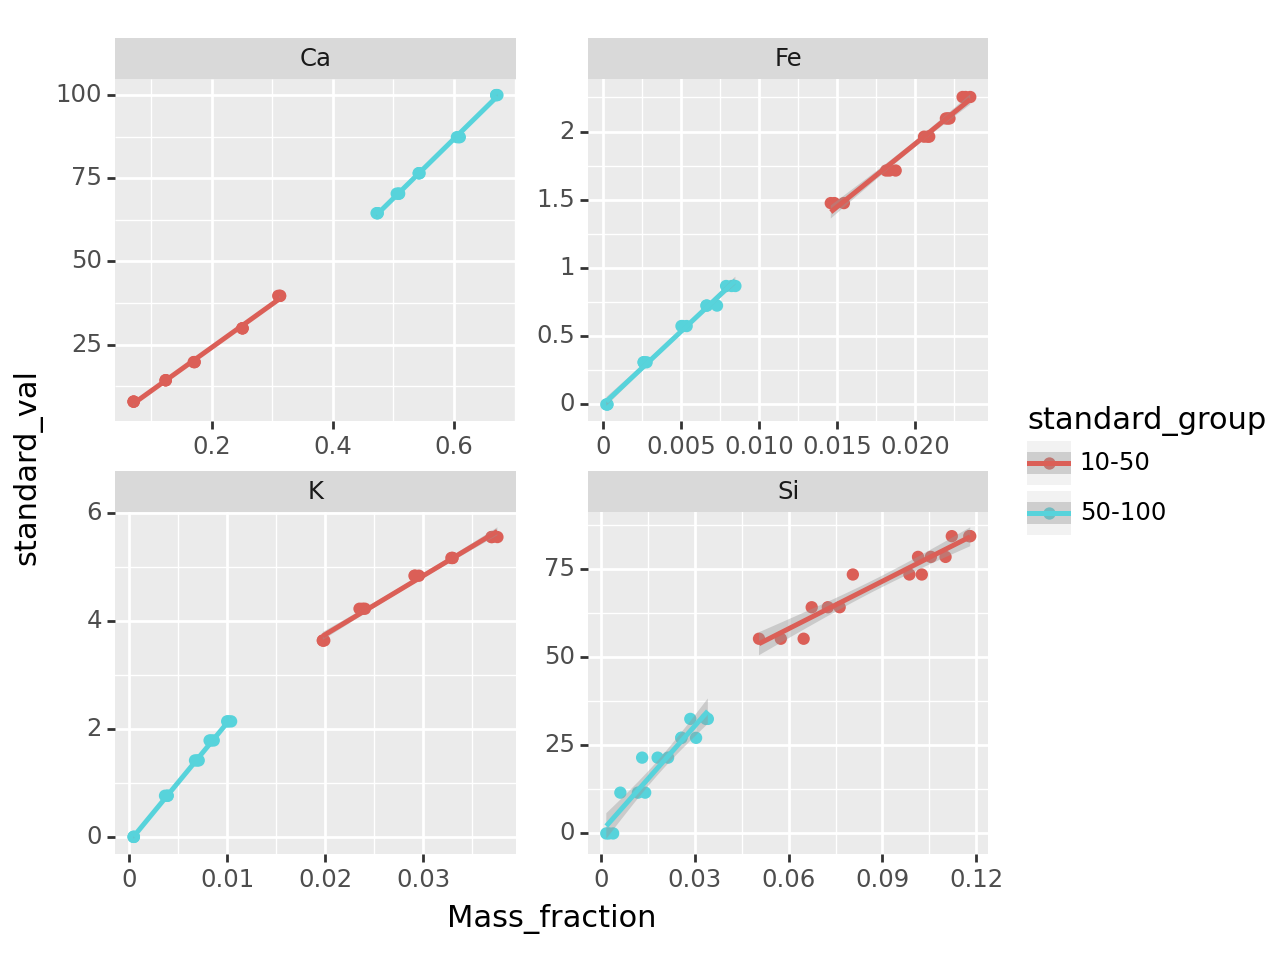

<Figure Size: (640 x 480)>

In [6]:
# @title Plot linear regressions
import plotnine as p9
fig=p9.ggplot(df.reset_index(), p9.aes(x='Mass_fraction', y='standard_val', color='standard_group'))
fig+=p9.geom_point()
fig+=p9.geom_smooth(method='lm')
fig+=p9.facet_wrap('Element', scales='free')
fig


In [7]:
# @title Calculate linear regressions, retrieving slope and intercept (standard_val = m * Mass_fraction + q)
# Calculate
def get_standard_slope_intercept(fn):
    df=parse_standards(fn)
    ld = []
    gby = ['Element','standard_group']
    for g,gdf in df.groupby(gby):
        X = gdf[['Mass_fraction']].values
        y = gdf['standard_val'].values

        # Create a linear regression model
        model = LinearRegression()
        fit = model.fit(X,y)
        m = model.coef_[0]
        q = model.intercept_
        d = dict(zip(gby,g))
        d['m']=m
        d['q']=q
        ld.append(d)
    return pd.DataFrame(ld)

get_standard_slope_intercept(fn)

,Element,standard_group,m,q
0,Ca,10-50,130.531084,-1.956683
1,Ca,50-100,178.659492,-20.349095
2,Fe,10-50,92.304145,0.062040
3,Fe,50-100,107.164364,-0.002138
4,K,10-50,109.162097,1.569634
5,K,50-100,221.324197,-0.099849
6,Si,10-50,449.220668,31.123401
7,Si,50-100,1003.534403,0.427805


## Parsing measurements (non-standards)

In [8]:
# @title Parse measurements and calculate new fractions according to relevant m & q values
# Design function to parse this output
import pandas as pd

def parse_measurements(fn):
    sdf=get_standard_slope_intercept(fn)
    # @title Enrich with descriptions
    df_desc=pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vS6kznqXRhvtB9QuPgTKVFEy4EzhP_FEMocpcbILy8YH1GUu7X5Q0mm2WNvdxBUSQ/pub?gid=1673331354&single=true&output=csv').fillna('')
    df_desc = df_desc.set_index('instrument').T
    df_desc.columns = [x.strip() for x in df_desc.columns]

    with open(fn) as f: txt=f.read()
    o=[]
    for srctxt in txt.strip().split('\n\n'):
        lines = srctxt.split('\n')
        src=lines[0].split(':')[-1].split('.csv')[0].strip()
        is_standard=src.replace('-','').isdigit()
        if is_standard: continue

        # get rest of data
        key=lines[1].split(':')[-1].strip()
        header=lines[2].split()
        data = [ln.split() for ln in lines[3:]]
        df = pd.DataFrame(data, columns=header).set_index('Element')
        df['Mass_fraction']=pd.to_numeric(df['Mass_fraction'], errors='coerce')

        # if ratio of Ca / Si > 10, then 50-100 curve; otherwise 10-50
        ca_si = df.loc['Ca']['Mass_fraction'] / df.loc['Si']['Mass_fraction']
        standard_group = '50-100' if ca_si>=10 else '10-50'
        df['standard_group'] = standard_group
        df = df.merge(sdf, on=['Element','standard_group'], how='inner')
        df['y'] = (df['m'] * df['Mass_fraction']) + df['q']
        df['Calc_fraction'] = df['y'] / df['y'].sum() * 100
        df['source_name']=src

        try:
            isic = src.split('-')[0][4:]
            isic_letter = src.split('-')[-1]

            desc_rows = df_desc[df_desc.Isic==isic]
            desc_col = desc_rows[isic_letter]
            desc = '; '.join(desc_col)
        except KeyError as e:
            print(f'Could not find {repr(isic_letter)} in logbook columns ({list(desc_rows.columns)})')
            desc = '?'

        df['desc'] = desc
        o.append(df)
    df=pd.concat(o)
    return df.set_index(['source_name','Element'])

odf = parse_measurements(fn)
odf

Group      Fit_Area Sigma_Area  Mass_fraction  \
source_name     Element                                                 
ISic000086-MK-a Si          K  1.509995e+01   5.09e+01       0.000830   
                K           K  1.074890e+04   1.60e+02       0.004916   
                Ca          K  8.371179e+05   9.35e+02       0.367500   
                Fe          K  5.944505e+04   2.77e+02       0.014330   
ISic000086-MK-b Si          K  2.551054e+02   5.38e+01       0.013890   
...                       ...           ...        ...            ...   
ISic003083-MK-b Fe          K  1.556744e+04   1.67e+02       0.003833   
ISic003083-MK-c Si          K  1.017047e+02   5.35e+01       0.005534   
                K           K  3.101045e+03   1.30e+02       0.001398   
                Ca          K  1.037633e+06   1.04e+03       0.451600   
                Fe          K  2.023437e+04   1.87e+02       0.004924   

                        standard_group            m          q          y  \
source_name     Element                                                     
ISic000086-MK-a Si              50-100  1003.534403   0.427805   1.260337   
                K               50-100   221.324197  -0.099849   0.988181   
                Ca              50-100   178.659492 -20.349095  45.308268   
                Fe              50-100   107.164364  -0.002138   1.533527   
ISic000086-MK-b Si              50-100  1003.534403   0.427805  14.366898   
...                                ...          ...        ...        ...   
ISic003083-MK-b Fe              50-100   107.164364  -0.002138   0.408623   
ISic003083-MK-c Si              50-100  1003.534403   0.427805   5.981365   
                K               50-100   221.324197  -0.099849   0.209562   
                Ca              50-100   178.659492 -20.349095  60.333532   
                Fe              50-100   107.164364  -0.002138   0.525539   

                         Calc_fraction          desc  
source_name     Element                               
ISic000086-MK-a Si            2.567385     yellow, v  
                K             2.012985     yellow, v  
                Ca           92.295740     yellow, v  
                Fe            3.123890     yellow, v  
ISic000086-MK-b Si           20.263465  yellow, back  
...                                ...           ...  
ISic003083-MK-b Fe            0.622423  after A, L 2  
ISic003083-MK-c Si            8.920753            pi  
                K             0.312546            pi  
                Ca           89.982899            pi  
                Fe            0.783802            pi  

[924 rows x 10 columns]

In [9]:
# @title Saving to excel
# Save
ofn = os.path.join(os.path.dirname(fn),'data.calculated_fractions.draft1.xlsx')
odf.to_excel(ofn)
print('Saved:',ofn)

Saved: /content/drive/MyDrive/Crossreads B D1/data.calculated_fractions.draft1.xlsx
